> *Dataset*

In [5]:
import numpy as np

np.random.seed(42)

# parameters
n_samples = 2000
n_features = 8
centers = 3
cluster_std = 0.6

In [10]:
from sklearn.datasets import make_blobs

# generate base clusters
X, y_true = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=n_features,
    cluster_std=cluster_std,
    random_state=42
)

In [13]:
# 5% outliers
n_outliers = int(0.05 * n_samples)
outliers = np.random.uniform(low=X.min(), high=X.max(), size=(n_outliers, n_features))

X= np.vstack([X, outliers])

In [15]:
import pandas as pd

# create dataframe
feature_names = [f"feature_{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)

In [19]:
print("Shape : ", df.shape)
print(df.head().to_string())

Shape :  (2100, 8)
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  feature_7  feature_8
0   0.591232   3.822296 -10.675504   8.827783   4.765744  -5.835412  -7.048666  -6.295967
1   1.593861   4.868503  -9.768019   8.656775   6.545628  -4.890316  -6.264357  -6.324397
2  -3.164470   9.095489   5.236547   2.360773  -8.302623  -5.654868  -8.661160   6.857623
3  -1.588508   9.687711   4.364020   2.299204  -6.877739  -6.142115  -8.248718   6.483480
4  -1.910392   7.276533   5.892904   1.889416  -6.214718  -7.504053  -8.470663   6.691474


- 2000 samples, but we now have 2100 because ~5% outliers (100 points) were appended.

> *Dataset Inspection*

In [25]:
print("\nMissing values per column:\n", df.isnull().sum(),"\n")


Missing values per column:
 feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
feature_8    0
dtype: int64 



In [27]:
print("\nData info:\n", df.info(),"\n")

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  2100 non-null   float64
 1   feature_2  2100 non-null   float64
 2   feature_3  2100 non-null   float64
 3   feature_4  2100 non-null   float64
 4   feature_5  2100 non-null   float64
 5   feature_6  2100 non-null   float64
 6   feature_7  2100 non-null   float64
 7   feature_8  2100 non-null   float64
dtypes: float64(8)
memory usage: 131.4 KB

Data info:
 None 



In [28]:
print("\nSummary statistics:\n", df.describe(),"\n")


Summary statistics:
          feature_1    feature_2  ...    feature_7    feature_8
count  2100.000000  2100.000000  ...  2100.000000  2100.000000
mean     -1.349719     4.277782  ...    -6.130931    -0.549673
std       2.913141     3.939541  ...     2.830334     5.856766
min     -10.744948   -10.861285  ...   -11.025195   -11.155378
25%      -3.553529     0.811702  ...    -8.434878    -5.910881
50%      -2.421366     4.072297  ...    -6.313015    -2.634051
75%       1.668450     8.551506  ...    -4.469882     6.894151
max      11.042527    10.945392  ...    10.589927    10.448863

[8 rows x 8 columns] 



> *Exploratory Analysis*

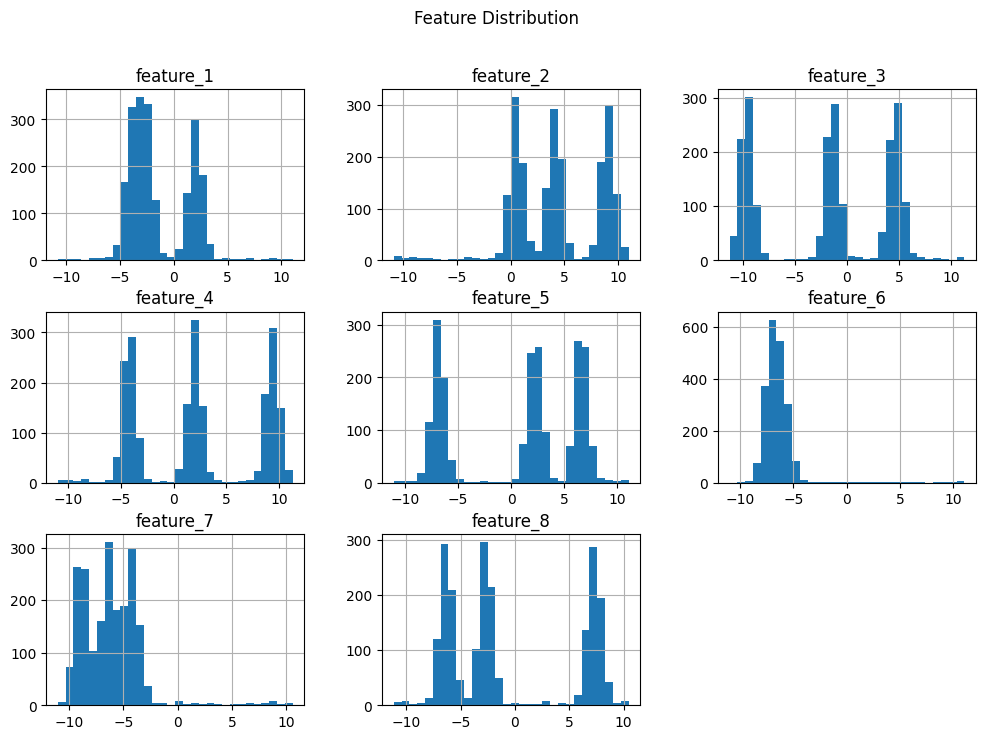

In [30]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(12, 8))
plt.suptitle("Feature Distribution")
plt.show()

In [ ]:
import seaborn as sns

plt.figure(figsize = (8,6))
sns.heatmap(df.corr(), annot=True, )